Quais são os estados que possuem um bom IDH para que possamos entregar bons produtos para os clientes?

In [95]:
# Libs - Exploração e manipulação de dados
import pandas as pd
import numpy as np

# Libs Gráficas
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Avisos
import warnings
warnings.filterwarnings("ignore")


In [96]:
idhm = pd.read_excel("IDH_2010.xls")
idhm.head()

,ANO,Código da Unidade da Federação,Nome da Unidade da Federação,Código do Município,Município,Esperança de vida ao nascer,Taxa de fecundidade total,Mortalidade infantil,Mortalidade até 5 anos de idade,Razão de dependência,...,População de 15 a 17 anos.1,População de 18 anos ou mais.1,População total em domicílios particulares permanentes,"População total em domicílios particulares permanentes, exceto com renda nula",Subíndice de escolaridade - IDHM Educação,Subíndice de frequência escolar - IDHM Educação,IDHM,IDHM Educação,IDHM Longevidade,IDHM Renda
0,2010,11,Rondônia,110001,ALTA FLORESTA D'OESTE,70.75,2.24,23.8,25.49,47.37,...,1602,16431,24097,22429,0.368,0.629,0.641,0.526,0.763,0.657
1,2010,11,Rondônia,110002,ARIQUEMES,73.36,1.91,19.2,20.53,46.68,...,5256,60213,89766,88730,0.514,0.648,0.702,0.600,0.806,0.716
2,2010,11,Rondônia,110003,CABIXI,70.39,2.15,24.8,26.58,48.12,...,381,4306,6303,6156,0.357,0.700,0.650,0.559,0.757,0.650
3,2010,11,Rondônia,110004,CACOAL,74.27,1.90,14.3,15.38,43.79,...,4547,54356,78141,76876,0.488,0.698,0.718,0.620,0.821,0.727
4,2010,11,Rondônia,110005,CEREJEIRAS,72.94,2.12,18.1,19.42,45.67,...,1033,11786,16942,16815,0.430,0.712,0.692,0.602,0.799,0.688


In [97]:
# Tamanho da base de dados
idhm.shape

(5564, 237)

In [98]:
# Existe valores nulos? Ordenar do maior para o menor
idhm.isnull().sum().sort_values(ascending=False)

ANO                                                0
Código da Unidade da Federação                     0
Nome da Unidade da Federação                       0
Código do Município                                0
Município                                          0
                                                  ..
Subíndice de frequência escolar - IDHM Educação    0
IDHM                                               0
IDHM Educação                                      0
IDHM Longevidade                                   0
IDHM Renda                                         0
Length: 237, dtype: int64

In [99]:
# Selecionar as colunas de interesse
df_idhm = idhm[["Nome da Unidade da Federação", "Município", "IDHM", "IDHM Educação", "IDHM Longevidade", "IDHM Renda"]]

In [100]:
# renomeia colunas para (uf, municipio, idhm, idhm_educacao, idhm_longevidade, idhm_renda)
df_idhm.columns = ['uf', 'municipio', 'idhm', 'idhm_educacao', 'idhm_longevidade', 'idhm_renda']

In [101]:
df_idhm.info()

<class 'pandas.DataFrame'>
RangeIndex: 5564 entries, 0 to 5563
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   uf                5564 non-null   str    
 1   municipio         5564 non-null   str    
 2   idhm              5564 non-null   float64
 3   idhm_educacao     5564 non-null   float64
 4   idhm_longevidade  5564 non-null   float64
 5   idhm_renda        5564 non-null   float64
dtypes: float64(4), str(2)
memory usage: 260.9 KB


In [102]:
# Valores únicos
df_idhm.nunique()

uf                    27
municipio           5329
idhm                 349
idhm_educacao        466
idhm_longevidade     220
idhm_renda           390
dtype: int64

In [103]:
df_idhm.describe().round(2)

,idhm,idhm_educacao,idhm_longevidade,idhm_renda
count,5564.00,5564.00,5564.00,5564.00
mean,0.66,0.56,0.80,0.64
std,0.07,0.09,0.04,0.08
min,0.42,0.21,0.67,0.40
25%,0.60,0.49,0.77,0.57
50%,0.66,0.56,0.81,0.65
75%,0.72,0.63,0.84,0.71
max,0.86,0.82,0.89,0.89


In [104]:
# Qual estado com maior IDHM?
df_idhm.groupby("uf")["idhm"].mean().sort_values(ascending=False).head(5)

uf
Distrito Federal     0.824000
São Paulo            0.739527
Santa Catarina       0.731648
Rio Grande do Sul    0.713530
Rio de Janeiro       0.708913
Name: idhm, dtype: float64

In [105]:
# Qual estado com maior IDHM Renda?
df_idhm.groupby("uf")["idhm_renda"].mean().sort_values(ascending=False).head(5)

uf
Distrito Federal     0.863000
Santa Catarina       0.728038
Rio Grande do Sul    0.722115
São Paulo            0.716487
Rio de Janeiro       0.704565
Name: idhm_renda, dtype: float64

In [106]:
# Função para classificar o IDHM de acordo com os seguintes critérios:
# - Muito baixo: IDHM < 0.500
# - Baixo: 0.500 <= IDHM < 0.600
# - Médio: 0.600 <= IDHM < 0.700
# - Alto: 0.700 <= IDHM < 0.800
# - Muito alto: IDHM >= 0.800
def classificar_idhm(idhm):
    if idhm < 0.500:
        return "Muito baixo"
    elif 0.500 <= idhm < 0.600:
        return "Baixo"
    elif 0.600 <= idhm < 0.700:
        return "Médio"
    elif 0.700 <= idhm < 0.800:
        return "Alto"
    else:
        return "Muito alto"

In [107]:
df_idhm["classificacao_idhm"] = df_idhm["idhm"].apply(classificar_idhm)

In [108]:
df_idhm["classificacao_idhm"].value_counts()

classificacao_idhm
Médio          2232
Alto           1889
Baixo          1367
Muito alto       44
Muito baixo      32
Name: count, dtype: int64

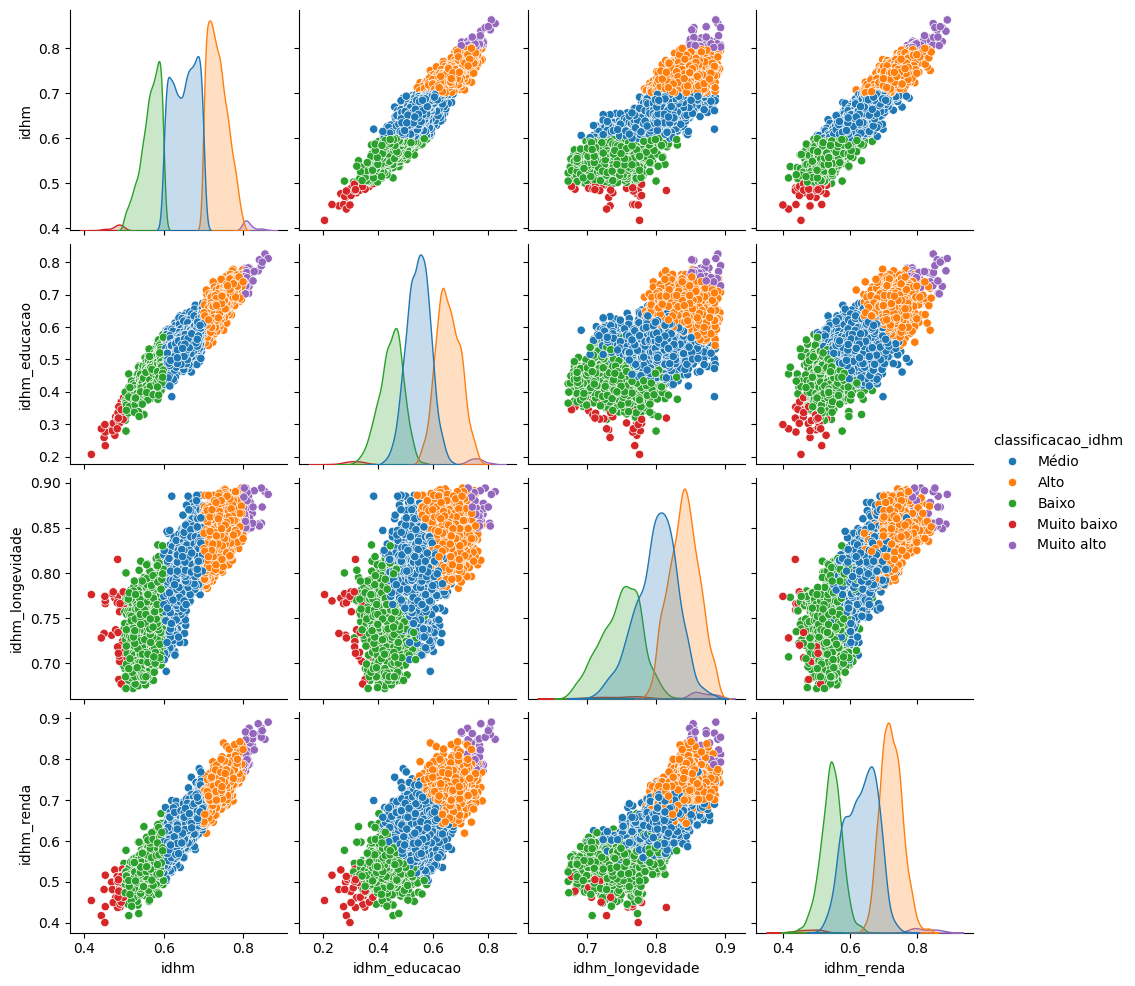

In [109]:
sns.pairplot(df_idhm, hue="classificacao_idhm")

In [110]:
# Análise por estado
df_idhm_estado = pd.DataFrame(df_idhm.groupby("uf")["idhm"].mean().round(2)).reset_index()

In [111]:
df_idhm_estado["classificacao_idhm"] = df_idhm_estado["idhm"].apply(classificar_idhm)

In [112]:
df_idhm_estado["classificacao_idhm"].value_counts()

classificacao_idhm
Médio         13
Baixo          8
Alto           5
Muito alto     1
Name: count, dtype: int64

In [113]:
# Exibe e ordena estados com melhor classificação de IDHM
df_idhm_estado.sort_values(by="idhm", ascending=False)

,uf,idhm,classificacao_idhm
6,Distrito Federal,0.82,Muito alto
25,São Paulo,0.74,Alto
23,Santa Catarina,0.73,Alto
19,Rio Grande do Sul,0.71,Alto
20,Rio de Janeiro,0.71,Alto
13,Paraná,0.70,Alto
7,Espírito Santo,0.69,Médio
8,Goiás,0.69,Médio
10,Mato Grosso,0.68,Médio
11,Mato Grosso do Sul,0.68,Médio


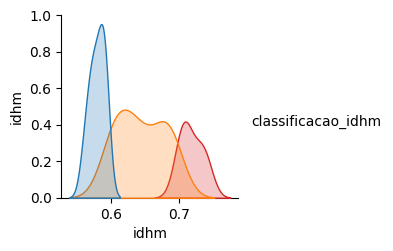

In [114]:


sns.pairplot(df_idhm_estado, hue="classificacao_idhm")

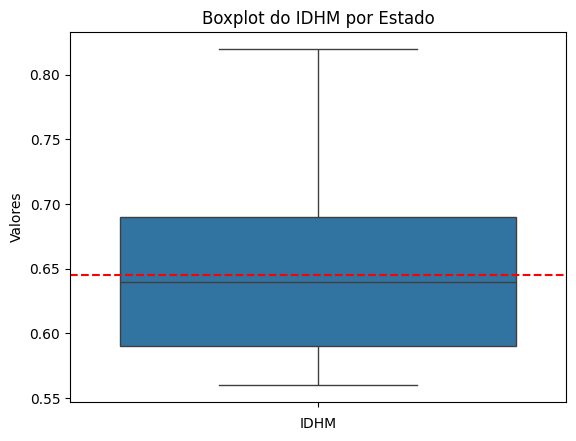

In [115]:
# gráfico de bloxplot do IDHM por estado
sns.boxplot(y=df_idhm_estado["idhm"], data=df_idhm_estado)

# Adicionar título e rótulos aos eixos
plt.title("Boxplot do IDHM por Estado")
plt.ylabel("Valores")
plt.xlabel("IDHM")

# Incluir a linha da média
plt.axhline(df_idhm_estado["idhm"].mean(), color="red", linestyle="--", label="Média")
plt.show()

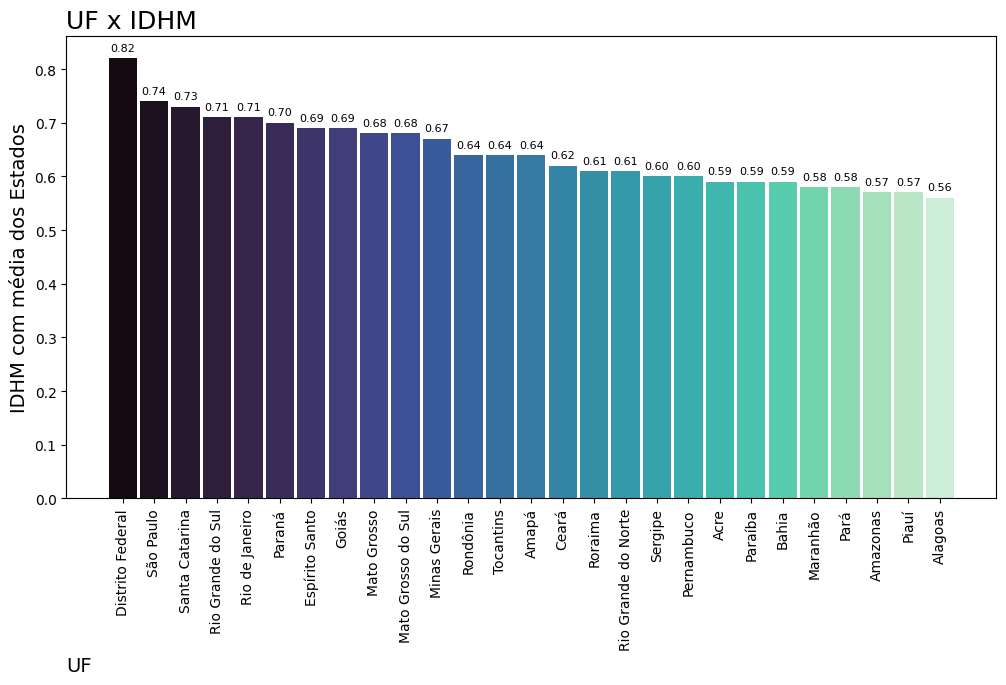

In [116]:
df_idhm_estado = df_idhm_estado.sort_values(by="idhm", ascending=False)

# Gerar gráfico no formato de dispersão (scatter plot) do IDHM por estado
plt.figure(figsize=(12, 6))

# Paleta de cores
Paleta_Cores = sns.color_palette('mako', len(df_idhm_estado))

# Plotagem 
plt.bar(df_idhm_estado["uf"],
        df_idhm_estado["idhm"],
        width=0.9,
        color=Paleta_Cores)

# Título
plt.title("UF x IDHM", loc = 'left', fontsize=18)

# Labels
plt.xlabel('UF', loc='left', fontsize=14)
plt.ylabel("IDHM com média dos Estados", fontsize=14)
plt.xticks(rotation=90)

# Incluir rótulo de dados
for i, (uf, idhm) in enumerate(zip(df_idhm_estado["uf"], df_idhm_estado["idhm"])):
    plt.text(i, idhm + 0.01, f'{idhm:.2f}', ha='center', va='bottom', fontsize=8)

# Ordenar os estados por IDHM do Maior para o Menor no gráfico de barras



plt.show()

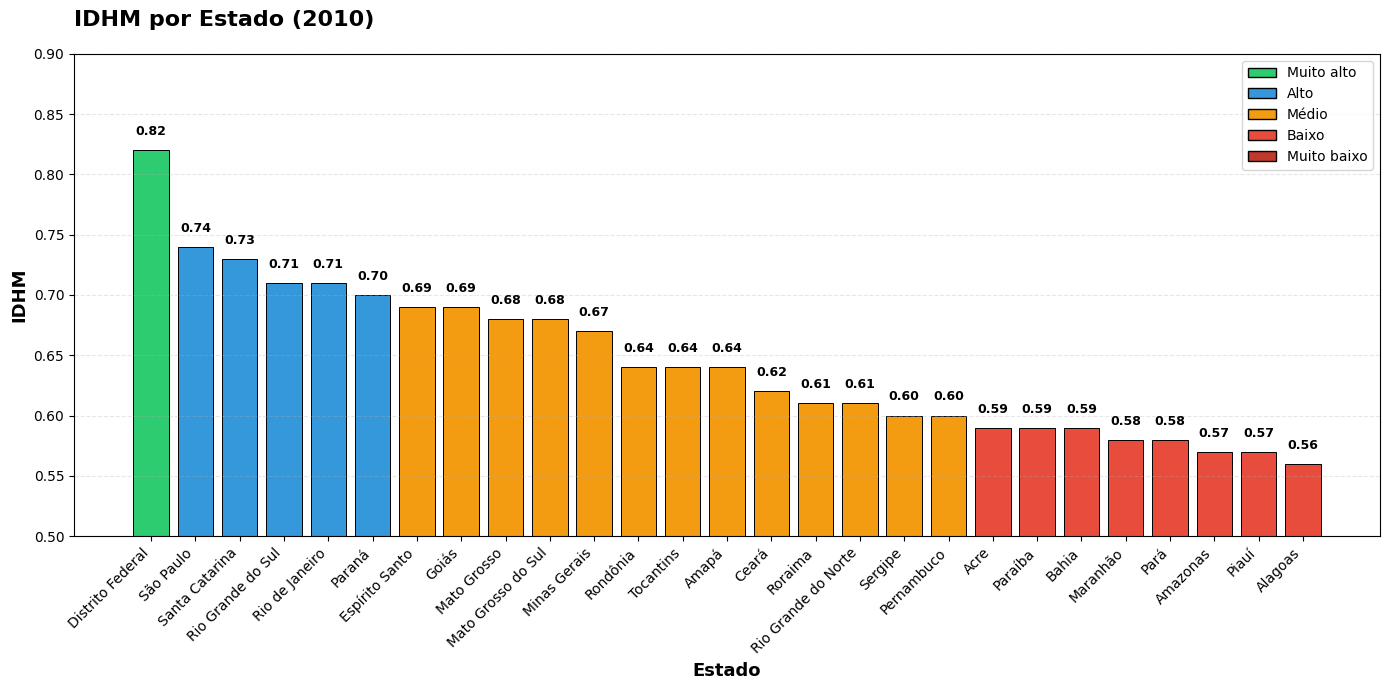

In [117]:
# Gráfico com matplotlib melhorado
plt.figure(figsize=(14, 7))

# Cores por classificação
cores = {'Muito alto': '#2ecc71', 'Alto': '#3498db', 'Médio': '#f39c12', 'Baixo': '#e74c3c', 'Muito baixo': '#c0392b'}
cores_lista = [cores[cat] for cat in df_idhm_estado['classificacao_idhm']]

# Criar gráfico de barras
bars = plt.bar(range(len(df_idhm_estado)), df_idhm_estado['idhm'], color=cores_lista, edgecolor='black', linewidth=0.7)

# Customização
plt.xlabel('Estado', fontsize=13, fontweight='bold')
plt.ylabel('IDHM', fontsize=13, fontweight='bold')
plt.title('IDHM por Estado (2010)', fontsize=16, fontweight='bold', loc='left', pad=20)
plt.xticks(range(len(df_idhm_estado)), df_idhm_estado['uf'], rotation=45, ha='right')
plt.ylim(0.5, 0.9)

# Adicionar valores nas barras
for i, (bar, valor) in enumerate(zip(bars, df_idhm_estado['idhm'])):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{valor:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Legenda
from matplotlib.patches import Patch
elementos_legenda = [Patch(facecolor=cores[cat], edgecolor='black', label=cat) 
                     for cat in ['Muito alto', 'Alto', 'Médio', 'Baixo', 'Muito baixo']]
plt.legend(handles=elementos_legenda, loc='upper right', fontsize=10)

# Grade
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

In [118]:

# Análise por estado, incluindo as outras classificações de IDHM
df_idhm_estado = pd.DataFrame(df_idhm.groupby("uf")[["idhm", "idhm_educacao", "idhm_longevidade", "idhm_renda"]].mean().round(2)).reset_index()

In [119]:
df_idhm_estado["classificacao_idhm"] = df_idhm_estado["idhm"].apply(classificar_idhm)

In [120]:
df_idhm_estado.head()

,uf,idhm,idhm_educacao,idhm_longevidade,idhm_renda,classificacao_idhm
0,Acre,0.59,0.45,0.77,0.59,Baixo
1,Alagoas,0.56,0.44,0.74,0.55,Baixo
2,Amapá,0.64,0.55,0.78,0.62,Médio
3,Amazonas,0.57,0.44,0.77,0.55,Baixo
4,Bahia,0.59,0.48,0.76,0.57,Baixo


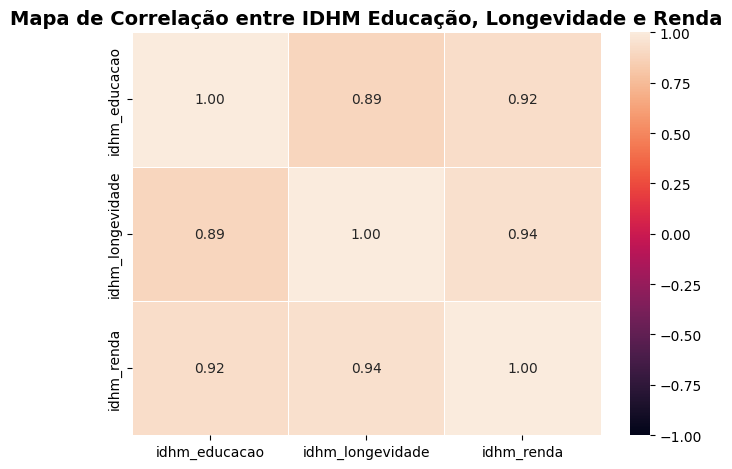

In [121]:
#heatmap de correlação entre as colunas do dataframe df_idhm_estado 
cols_corr = [c for c in ["idhm_educacao", "idhm_longevidade", "idhm_renda"] if c in df_idhm_estado.columns]
corr = df_idhm_estado[cols_corr].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="rocket", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Mapa de Correlação entre IDHM Educação, Longevidade e Renda", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

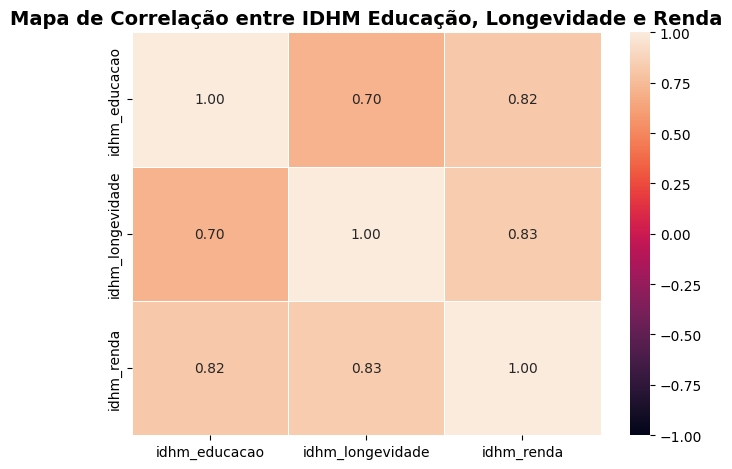

In [122]:
#heatmap de correlação entre as colunas do dataframe df_idhm
cols_corr = [c for c in ["idhm_educacao", "idhm_longevidade", "idhm_renda"] if c in df_idhm.columns]
corr = df_idhm[cols_corr].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="rocket", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Mapa de Correlação entre IDHM Educação, Longevidade e Renda", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [123]:
df_idhm = df_idhm.sort_values(by=["uf", "idhm"], ascending=False)

In [126]:
# Qual a mediana do estado de Goiás?
df_idhm_estado_med = df_idhm.groupby("uf")["idhm"].median().reset_index

In [ ]:
# Adicionar coluna com mediana do estado para cada município
df_idhm['mediana_estado'] = df_idhm.groupby('uf')['idhm'].transform('median').round(2)

# Ordenar pela mediana do estado e depois pelo IDHM do município
df_idhm = df_idhm.sort_values(by=['mediana_estado', 'idhm'], ascending=False)

In [88]:
# exibe os distintos agrupados por estado uf da coluna idhm_median
df_idhm_estado_lt = df_idhm_estado.groupby("uf")["idhm_median"].first().reset_index().sort_values(by="idhm_median", ascending=False)

In [84]:
# Qantos municípios em Goiás?
df_idhm[df_idhm["uf"] == "Goiás"]["municipio"].nunique()

246

In [86]:
# Ordenar df_idhm por ordem alfabética do estado e do IDHM do maior para o menor
df_idhm = df_idhm.sort_values(by=["uf", "idhm"], ascending=False)   

In [87]:
# Mediana do IDHM dos municípios de Goiás
df_idhm[df_idhm["uf"] == "Goiás"]["idhm"].median()

np.float64(0.697)

In [125]:
df_idhm_estado_lt.head(30)

,uf,idhm_median
8,Goiás,0.82
3,Amazonas,0.74
0,Acre,0.74
16,Pernambuco,0.72
5,Ceará,0.71
14,Paraíba,0.71
10,Mato Grosso,0.70
12,Minas Gerais,0.69
7,Espírito Santo,0.68
2,Amapá,0.68


In [ ]:
# Boxplot por estado ordenado pela mediana do IDHM (maior para menor)
plt.figure(figsize=(16, 6))

# Criar ordem dos estados pela mediana (decrescente)
ordem_estados = df_idhm.groupby('uf')['mediana_estado'].first().sort_values(ascending=False).index.tolist()

# Boxplot ordenado
sns.boxplot(data=df_idhm, x='uf', y='idhm', order=ordem_estados, palette='Set2')

plt.title('Distribuição de IDHM por Estado (Ordenado pela Mediana)', fontsize=16, fontweight='bold', loc='left', pad=20)
plt.xlabel('Estado', fontsize=13, fontweight='bold')
plt.ylabel('IDHM', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')

# Linha de referência com a média geral
plt.axhline(df_idhm['idhm'].mean(), color='red', linestyle='--', linewidth=2, label=f"Média geral: {df_idhm['idhm'].mean():.3f}")
plt.legend(loc='lower right', fontsize=11)

# Grade
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()